## <font color="brown">📙&nbsp;&nbsp;Introduction</font>

The travelling salesman problem (TSP) asks the following question: Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city? It is an NP-hard problem in combinatorial optimization, important in operations research and theoretical computer science \[Wikipedia\].

## <font color="brown">🎯&nbsp;&nbsp;Task</font>
The objective of this exercise is to solve the TSP problem for a set of 14 cities in Burma, officially the Republic of the Union of Myanmar. The following vectors give the GPS position of each city.

   LAT = [16.47, 16.47, 20.09, 22.39, 25.23, 22.00, 20.47, 
          17.20, 16.30, 14.05, 16.53, 21.52, 19.41, 20.09]

   LON = [96.10, 94.44, 92.54, 93.37, 97.24, 96.05, 97.02, 
          96.29, 97.38, 98.12, 97.38, 95.59, 97.13, 94.55]
  
**<font color="green">BONUS:</font>** Consider that the distance between two cities is not the Euclidean distance. You have to consider that they are points on the surface of the Earth, which can be considered to be an oblate spheroid.

## <font color="brown">📝&nbsp;&nbsp;Report</font>


1. Provide the better route you found and the shortest path in kilometers. Is it the optimal shortest path ? explain.
2. Describe your fitness function
3. Explain the way you encoded the solution, give a chromosome example.
4. Provide the configuration of the GA you finally used to find your better results: mutation, crossover, population size, type of selection, mutation, crossover used, number of generations. Describe the methodology or experiments performed in order to get your better results.
5. Provide relevant plots of your experiments and explanations.

**Submit your notebook as well**

14
Starting genetic algorithm to solve the TSP for 14 cities in Burma...
----------------------------------------------------------------------

Generation 50: Best Distance = 3392.19 km: Fitness: 0.00029479504970042974
Solution: [ 6 12  7  0 10  8  9  1 13  2  3  4  5 11]

Generation 100: Best Distance = 3354.52 km: Fitness: 0.0002981049642579218
Solution: [ 6 12  7 10  8  9  0  1 13  2  3  4  5 11]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


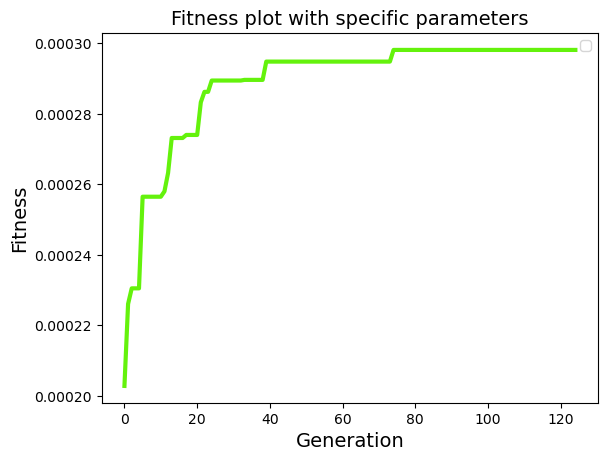

Min. distance: 3354.523137477158 km
Best solution: [ 6 12  7 10  8  9  0  1 13  2  3  4  5 11  6]


In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pygad
import math


LAT = [16.47, 16.47, 20.09, 22.39, 25.23, 22.00, 20.47, 
          17.20, 16.30, 14.05, 16.53, 21.52, 19.41, 20.09]

LON = [96.10, 94.44, 92.54, 93.37, 97.24, 96.05, 97.02, 
          96.29, 97.38, 98.12, 97.38, 95.59, 97.13, 94.55]

COORDINATES = [{"lat": lat, "lon": lon} for lat, lon in zip(LAT, LON)]

NUM_CITIES = len(LAT)
print(NUM_CITIES)

#print(COORDINATES)

#print(COORDINATES[1]["lat"])

def euclidian_distance(city_a, city_b):
       return math.sqrt((city_a["lat"]-city_b["lat"])**2 + (city_a["lon"]-city_b["lon"])**2)

def haversine_distance(city_a, city_b):
       # Earth radius in kilometers
       R = 6371.0

       # Convert latitude and longitude from degrees to radians
       lat1 = math.radians(city_a["lat"])
       lon1 = math.radians(city_a["lon"])
       lat2 = math.radians(city_b["lat"])
       lon2 = math.radians(city_b["lon"])

       # Calculate differences
       dlat = lat2 - lat1
       dlon = lon2 - lon1
       
       # Haversine formula
       a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
       c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
       
       # Distance in kilometers
       distance = R * c
       
       return distance


def create_distance_matrix(coordinates, distance_func):
       n = len(coordinates)
       distance_matrix = np.zeros((n, n))

       for i in range(n):
              for j in range(n):
                     if i!= j:
                            distance_matrix[i][j] = distance_func(coordinates[i], coordinates[j])
       
       return distance_matrix

distance_matrix = create_distance_matrix(COORDINATES, haversine_distance)

fitness_history = []
best_solution_history = []

def calculate_tour_distance(tour, dist_matrix):
       distance = 0

       for i in range(NUM_CITIES):
              from_city = tour[i]
              to_city = tour[(i + 1) % NUM_CITIES] # the city at index 13 will go back to the first city !
              distance += dist_matrix[from_city][to_city]
       
       return distance


def fitness_function(ga_instance, solution, solution_idx):
       
       tour_distance = calculate_tour_distance(solution, distance_matrix)
       #print(tour_distance)

       # Return fitness (smaller distance = higher fitness)
       if tour_distance == 0:
              return 0
       return 1.0 / tour_distance


def on_generation(ga_instance):

       solution, solution_fitness, solution_idx = ga_instance.best_solution()

       best_distance = calculate_tour_distance(solution, distance_matrix)
    
       fitness_history.append(best_distance)
       best_solution_history.append(solution.copy())
    
       # Display progress periodically
       if ga_instance.generations_completed % 50 == 0:
              print(f"\nGeneration {ga_instance.generations_completed}: Best Distance = {best_distance:.2f} km: Fitness: {solution_fitness}")
              print(f"Solution: {solution}")
       
# Custom initialization function
def custom_init_population():
    population = np.zeros((POPULATION, NUM_CITIES), dtype=int)
    for i in range(POPULATION):
        population[i, :] = np.random.permutation(NUM_CITIES)
    return population

# Create initial population of valid permutations
# initial_population = custom_init_population()


NUM_GENERATIONS = 1000
POPULATION = 400
PARENTS_MATING = 30
MUTATION_PROBA = 0.2
CROSSOVER_PROBA = 0.9
MUTATION_TYPE = "random"
PARENT_SELECTION_TYPE = "tournament"

gene_space = [list(range(NUM_CITIES))] * NUM_CITIES

# Create and run the genetic algorithm
ga_instance = pygad.GA(
    #initial_population=initial_population,   
    sol_per_pop=POPULATION,
    num_genes=NUM_CITIES,
    num_generations=NUM_GENERATIONS,
    num_parents_mating=PARENTS_MATING,
    fitness_func=fitness_function,
    gene_space=gene_space,
    gene_type=int,
    on_generation=on_generation,
    mutation_type=MUTATION_TYPE,
    mutation_probability=MUTATION_PROBA,
    random_mutation_min_val=0,
    random_mutation_max_val=NUM_CITIES,
    crossover_type="single_point",
    crossover_probability=CROSSOVER_PROBA,
    parent_selection_type=PARENT_SELECTION_TYPE,
    K_tournament=5,
    allow_duplicate_genes=False,
    keep_parents=5,
    stop_criteria=["reach_1000", "saturate_50"]
)

print("Starting genetic algorithm to solve the TSP for 14 cities in Burma...")
print("-" * 70)
ga_instance.run()
ga_instance.plot_fitness(title=f"Fitness plot with specific parameters", save_dir=f"./tsp_result/plot_fitness_pst_{PARENT_SELECTION_TYPE}_mt_{MUTATION_TYPE}_cp{CROSSOVER_PROBA}_mp{MUTATION_PROBA}.png")

# Get the best solution
#solution, solution_fitness, solution_idx = ga_instance.best_solution()
#best_route = solution

# Calculate the final distance
#best_distance = calculate_tour_distance(best_route, dist_matrix=distance_matrix)

# Display the best solution
#print("\nBest Route Found:")
#route_with_return = np.append(best_route, best_route[0])
#print(route_with_return)

# Best distance
#print("\nBest Distance Found:")
#print(f"{best_distance:.2f} km")

# Best fitness
#print("\nBest Fitness:")
#print(f"{solution_fitness}")

minimum_distance = min(fitness_history)
minimum_index = fitness_history.index(minimum_distance)
best_solution = best_solution_history[minimum_index]
best_solution_with_return = np.append(best_solution, best_solution[0])

print(f"Min. distance: {minimum_distance} km")
print(f"Best solution: {best_solution_with_return}")


In [2]:
from python_tsp.exact import solve_tsp_dynamic_programming

permutation, distance = solve_tsp_dynamic_programming(distance_matrix)

print(f"Optimal solution: {permutation}")
print(f"Optimal distance: {distance}")

# To check if everything is okay ^^
optimal_distance = calculate_tour_distance(permutation, distance_matrix)
print(f"Calculated optimal distance: {optimal_distance}")


Optimal solution: [0, 9, 8, 10, 7, 12, 6, 11, 5, 4, 3, 2, 13, 1]
Optimal distance: 3354.5231374771574
Calculated optimal distance: 3354.523137477158
